In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Read Dataset
df = pd.read_excel("/content/Smart_Healthcare_Analytics_Dataset.xlsx")

In [3]:
print("First 5 Rows")
print(df.head())

print("\nDataset Shape")
print(df.shape)

print("\nColumn Names")
print(df.columns)

print("\nData Types")
print(df.dtypes)

First 5 Rows
  Patient_ID Admission_Date Discharge_Date  Age  Gender           State  \
0     P00001     2025-04-08     2025-04-09   85    Male       Karnataka   
1     P00002     2025-10-28     2025-11-07   36  Female     Maharashtra   
2     P00003     2025-06-11     2025-06-13   38    Male  Andhra Pradesh   
3     P00004     2025-10-27     2025-10-28   37  Female       Telangana   
4     P00005     2025-10-11     2025-10-18   48    Male  Andhra Pradesh   

         City      Hospital       Disease           Department      Doctor  \
0   Bengaluru      LifeCare  Hypertension           Cardiology  Dr. Sharma   
1        Pune      LifeCare  Hypertension           Cardiology  Dr. Sharma   
2  Vijayawada   Apollo Care        Dengue     General Medicine     Dr. Rao   
3   Hyderabad  Green Valley      COVID-19  Infectious Diseases   Dr. Singh   
4  Vijayawada      LifeCare        Dengue     General Medicine   Dr. Singh   

    Treatment    Outcome   Cost Insurance Blood_Group   BMI Smoking

In [4]:
df.fillna(method='ffill', inplace=True)

/tmp/ipykernel_1198/3970806690.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


In [5]:
print(df.describe(include='object'))

       Patient_ID  Gender        State  City      Hospital       Disease  \
count        5000    5000         5000  5000          5000          5000   
unique       5000       2            5     5             5             5   
top        P05000  Female  Maharashtra  Pune  Green Valley  Hypertension   
freq            1    2532         1013  1013          1030          1032   

        Department     Doctor Treatment   Outcome Insurance Blood_Group  \
count         5000       5000      5000      5000      5000        5000   
unique           5          5         4         4         2           7   
top     Cardiology  Dr. Patel   Therapy  Deceased        No          O-   
freq          1032       1061      1270      1286      2571         753   

       Smoking Diabetes_History Hypertension  
count     5000             5000         5000  
unique       2                2            2  
top         No               No           No  
freq      2544             2529         2514  


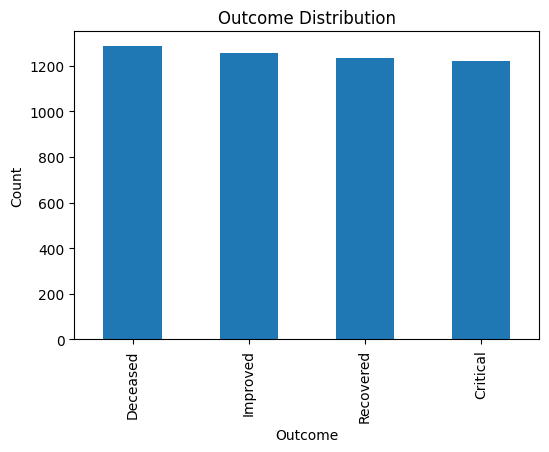

In [7]:
df.drop_duplicates(inplace=True)
df['Outcome'].value_counts().plot(
    kind='bar',
    figsize=(6,4)
)

plt.title("Outcome Distribution")
plt.xlabel("Outcome")
plt.ylabel("Count")
plt.show()

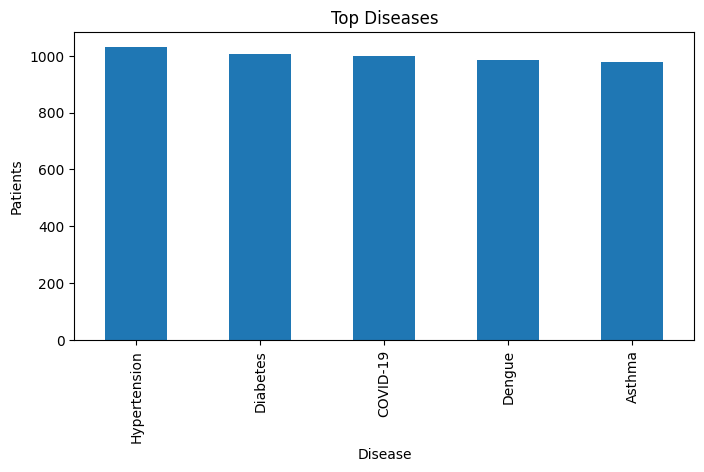

In [8]:
df['Disease'].value_counts().head(10).plot(
    kind='bar',
    figsize=(8,4)
)

plt.title("Top Diseases")
plt.xlabel("Disease")
plt.ylabel("Patients")
plt.show()

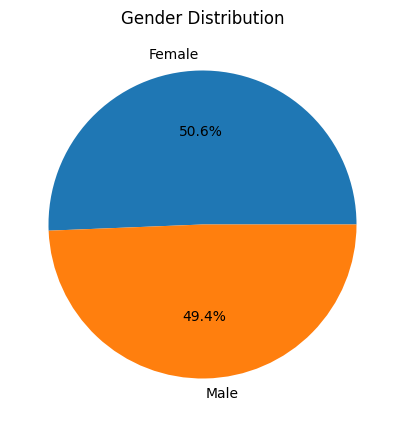

In [9]:
df['Gender'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(5,5)
)

plt.ylabel("")
plt.title("Gender Distribution")
plt.show()

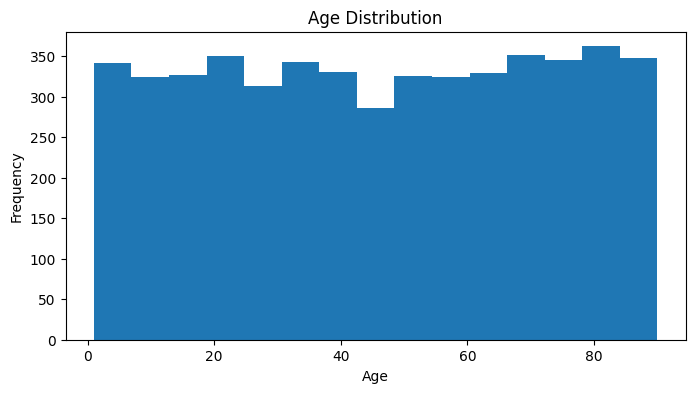

In [10]:
plt.figure(figsize=(8,4))

plt.hist(df['Age'], bins=15)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

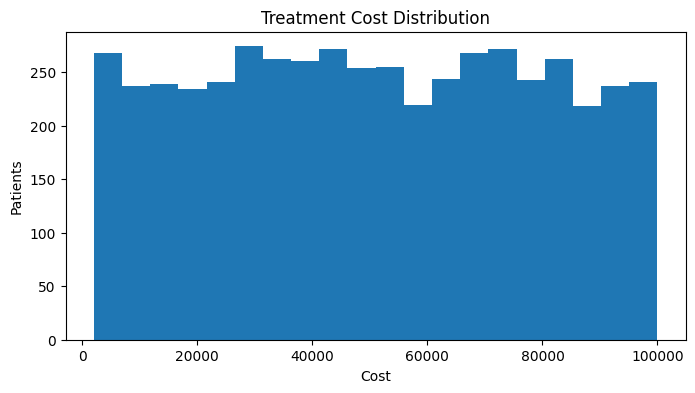

In [12]:
plt.figure(figsize=(8,4))

plt.hist(df['Cost'], bins=20)

plt.title("Treatment Cost Distribution")
plt.xlabel("Cost")
plt.ylabel("Patients")

plt.show()

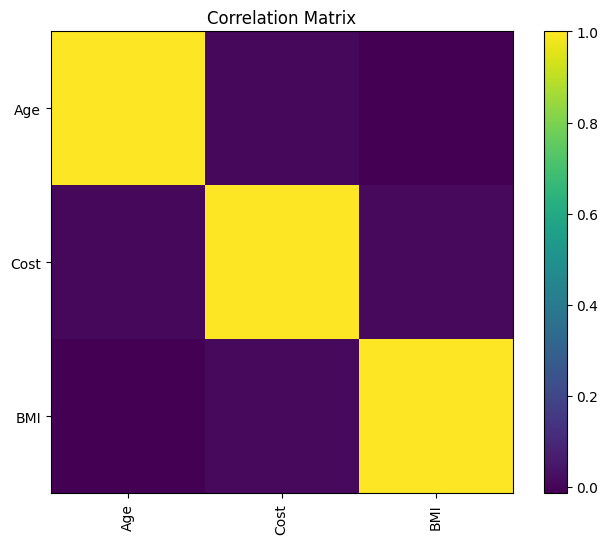

In [13]:
numeric_df = df.select_dtypes(include=['number'])

correlation = numeric_df.corr()

plt.figure(figsize=(8,6))

plt.imshow(correlation)

plt.xticks(range(len(correlation.columns)), correlation.columns, rotation=90)
plt.yticks(range(len(correlation.columns)), correlation.columns)

plt.colorbar()

plt.title("Correlation Matrix")

plt.show()

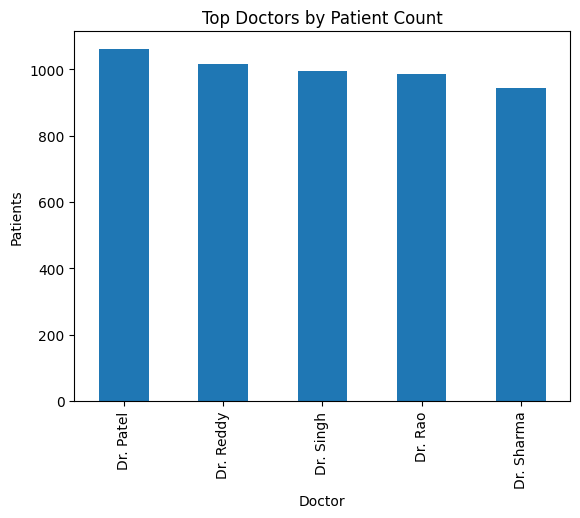

In [14]:
df['Doctor'].value_counts().head(10).plot(
    kind='bar'
)

plt.title("Top Doctors by Patient Count")
plt.xlabel("Doctor")
plt.ylabel("Patients")

plt.show()

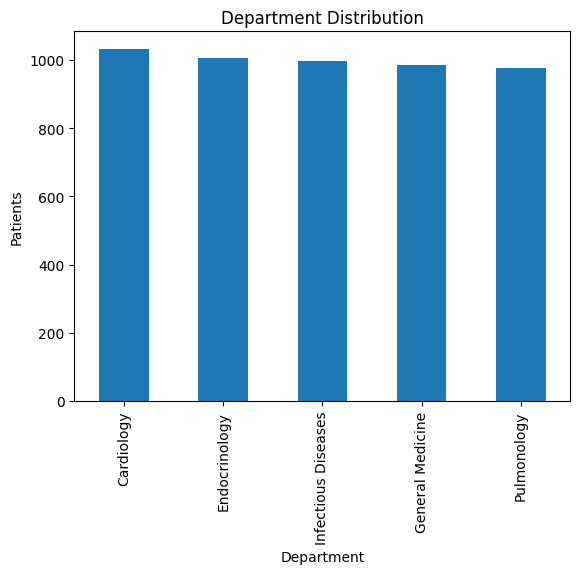

In [15]:
df['Department'].value_counts().plot(
    kind='bar'
)

plt.title("Department Distribution")
plt.xlabel("Department")
plt.ylabel("Patients")

plt.show()

In [16]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Remove unnecessary column (if exists)
if "Patient_ID" in df.columns:
    df.drop("Patient_ID", axis=1, inplace=True)

# Convert date columns into hospital stay
if "Admission_Date" in df.columns and "Discharge_Date" in df.columns:
    df["Admission_Date"] = pd.to_datetime(df["Admission_Date"])
    df["Discharge_Date"] = pd.to_datetime(df["Discharge_Date"])

    df["Hospital_Stay"] = (
        df["Discharge_Date"] - df["Admission_Date"]
    ).dt.days

    df.drop(["Admission_Date", "Discharge_Date"], axis=1, inplace=True)

# Handle missing values
df.fillna(method='ffill', inplace=True)

# Encode categorical columns
encoder = LabelEncoder()

for col in df.columns:
    if df[col].dtype == "object":
        df[col] = encoder.fit_transform(df[col].astype(str))

# Features and Target
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Train Random Forest
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", round(accuracy * 100, 2), "%")

print("\nClassification Report\n")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix\n")
print(confusion_matrix(y_test, y_pred))

/tmp/ipykernel_1198/2300210588.py:23: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


Accuracy: 23.8 %

Classification Report

              precision    recall  f1-score   support

           0       0.24      0.22      0.23       245
           1       0.25      0.28      0.27       257
           2       0.26      0.24      0.24       251
           3       0.21      0.21      0.21       247

    accuracy                           0.24      1000
   macro avg       0.24      0.24      0.24      1000
weighted avg       0.24      0.24      0.24      1000


Confusion Matrix

[[53 81 51 60]
 [51 73 59 74]
 [59 65 59 68]
 [58 74 62 53]]
